# Double Sided LBTI-NOMIC Data

This notebook is for pre-processing of double-sided LBTI-NOMIC data starting from the raw data.

In [1]:
import pyNOMIC.preprocessing as prep
import pyNOMIC.data_setup as ds
import pyNOMIC.helper_functions as hf
import pyNOMIC.frame_evaluation as fe
import shutil, pathlib, os
import numpy as np
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from astropy.io import fits
from tqdm.auto import tqdm

### File path

Enter directory containing raw files, the name of the star as it exists in the FITS headers, and its approximate temperature (for PSF fitting).

In [2]:
raw_dir = "raw"
obj='GJ504'
stellar_temp = 6200

# Important to sort the data for reading it sequentially
raw_files = sorted(list(pathlib.Path(str(raw_dir)).rglob('*.fits')))
raw_files = np.asarray([a for a in raw_files if a.name[0]!='.' and str(a.parent)==raw_dir])

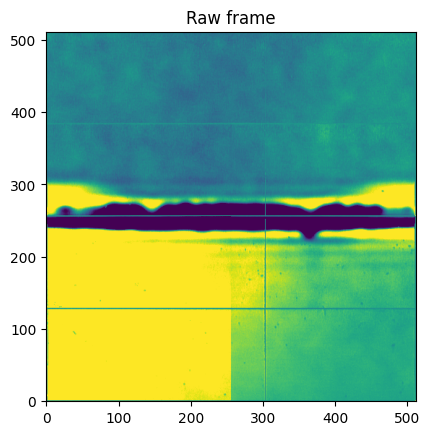

In [3]:
hdul = fits.open(raw_files[7857])
hdul2 = fits.open(raw_files[7858])
plt.title("Raw frame")
plt.imshow((hdul[0].data[0] - hdul2[0].data[0]),
           origin="lower", vmin=-400, vmax=400)
hdul.close()
plt.show()

### Create badmap, temporary flat, and highpass filter mask

We first create a badmap to filter out dead pixels/columns, a temporary flat for use in chop state identification, and a highpass filter mask to avoid edge artifacts.

In [ ]:
# This function creates the temporary flat and badmap
tempflat, badmap, _ = ds.create_badmap(raw_files, smooth=30, sigma=.5, tolerance=0.1)

# We create the high pass filter mask here
highpassmask = np.ones(np.shape(badmap))
highpassmask[190:310,:] = 0
highpassmask[:30,:] = 0
highpassmask[480:,:] = 0
highpassmask[:,480:] = 0
highpassmask[:,:30] = 0

# Save all three images
hdul = fits.HDUList([fits.PrimaryHDU(data=tempflat)])
hdul.writeto(obj+"_tempflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=badmap)])
hdul.writeto(obj+"_badmap.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=highpassmask)])
hdul.writeto(obj+"_highpassmask.fits", overwrite=True)
hdul.close()

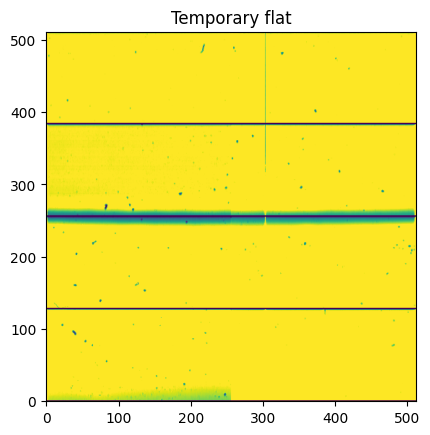

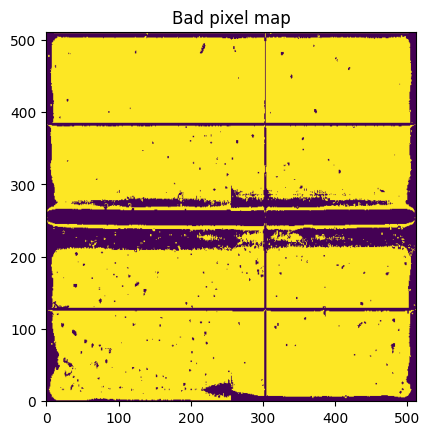

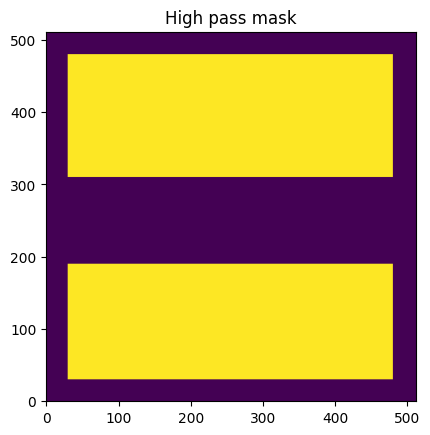

In [12]:
plt.title("Temporary flat")
plt.imshow(tempflat, origin="lower", vmin=14000, vmax=25000)
plt.show()

plt.title("Bad pixel map")
plt.imshow(badmap, origin="lower")
plt.show()

plt.title("High pass mask")
plt.imshow(highpassmask, origin="lower")
plt.show()

### Create high pass filtered frames and parallactic angles

We use the `setup_data` function to create high pass filtered frames for chop identification and obtain frame medians and parallactic angles. The chop states from the headers are also retrieved, but are usually not useful. The images/masks from earlier are inputs into this function. Frames above the default frame median limit are discarded. This function also splits the dataset into each side, SX and DX.

In [ ]:
(uncorrected_files, 
 uncorrected_chops, 
 uncorrected_header_info) = ds.setup_data(obj, raw_dir, double_side=True, recalc_para_angles=True,
                                          frame_median_limit = 28000, cold_stop_crop=50)
# Save to npz
np.savez(obj+"_NOMIC_getdata.npz", uncorrected_files,
         uncorrected_chops, uncorrected_header_info)
         
print("Files saved")

### Identify chops and create coadded frames

We identify the chop states of all the raw images using frame medians and coadd any consecutive chops as necessary. We also edit our file list and parallactic angles to match the list. The coadded frames are saved in a separate directory and the file list is amended to include the coadded frames and exclude the parent raw frames.

In [ ]:
(sx_orig_chops,
 sx_orig_frame_medians,
 sx_chopm) = ds.frame_med_chop_identification(_,
                                              files=uncorrected_files[0],
                                              size=9)

np.savez(obj+"_SX_NOMIC_chopidentification.npz", sx_orig_chops,
         sx_orig_frame_medians, sx_chopm)

(dx_orig_chops,
 dx_orig_frame_medians,
 dx_chopm) = ds.frame_med_chop_identification(_,
                                              files=uncorrected_files[1],
                                              size=3)

np.savez(obj+"_DX_NOMIC_chopidentification.npz", dx_orig_chops,
         dx_orig_frame_medians, dx_chopm)

print("Files saved")

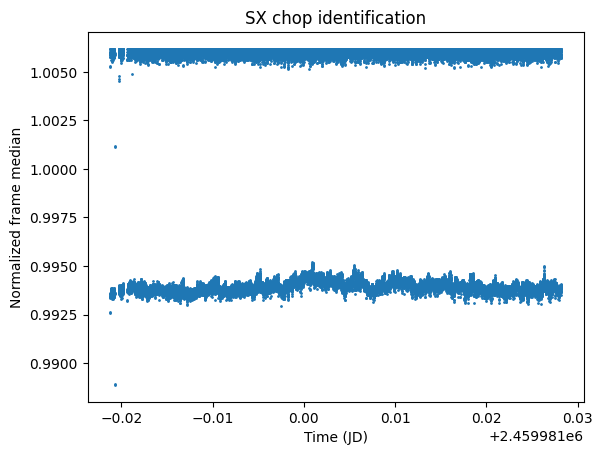

SX: Number of frames in CHOP A:  18903
SX: Number of frames in CHOP B:  19159


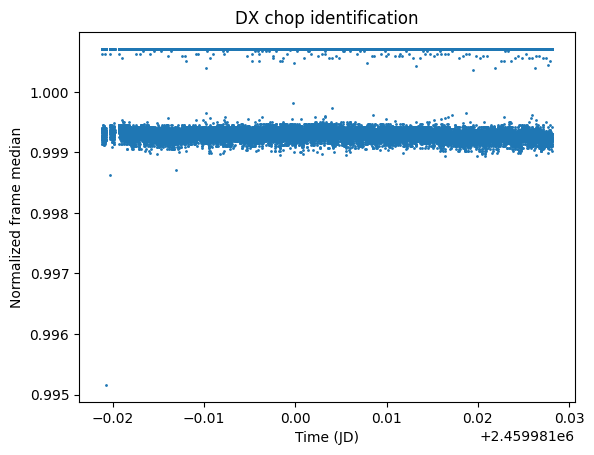

DX: Number of frames in CHOP A:  19045
DX: Number of frames in CHOP B:  19017


In [7]:
plt.title("SX chop identification")
plt.scatter(uncorrected_header_info[2], sx_chopm, s=1)
plt.xlabel("Time (JD)")
plt.ylabel("Normalized frame median")
plt.show()

print("SX: Number of frames in CHOP A: ", len(sx_orig_chops[sx_orig_chops == "CHOP_A"]))
print("SX: Number of frames in CHOP B: ", len(sx_orig_chops[sx_orig_chops == "CHOP_B"]))

plt.title("DX chop identification")
plt.scatter(uncorrected_header_info[2], dx_chopm, s=1)
plt.xlabel("Time (JD)")
plt.ylabel("Normalized frame median")
plt.show()

print("DX: Number of frames in CHOP A: ", len(dx_orig_chops[dx_orig_chops == "CHOP_A"]))
print("DX: Number of frames in CHOP B: ", len(dx_orig_chops[dx_orig_chops == "CHOP_B"]))

In [8]:
sx_orig_header_info = np.concatenate(([sx_orig_frame_medians], uncorrected_header_info[1:]))
dx_orig_header_info = np.concatenate(([dx_orig_frame_medians], uncorrected_header_info[1:]))

In [ ]:
(sx_files,
 sx_chops,
 sx_header_info,
 _) = ds.chop_correction(uncorrected_files[0], sx_orig_chops,
                                      sx_orig_header_info)

np.savez(obj+"_SX_NOMIC_chop_correction.npz", sx_files, sx_chops,
         sx_header_info)

(dx_files,
 dx_chops,
 dx_header_info,
 _) = ds.chop_correction(uncorrected_files[1], dx_orig_chops,
                                      dx_orig_header_info)

np.savez(obj+"_DX_NOMIC_chop_correction.npz", dx_files, dx_chops,
         dx_header_info)

print("Files saved")

### Create more flats!

The temporary flat we created earlier was a good proxy for identifying chop states, but now that we have the chop states, we can construct a better flat that omits the stellar PSF for each chop state. First, we create new bad pixel maps for each side. Then, we create a "combined" flat with the function `create_stacked_flat` that uses the halves of the image from each chop state that do not have the stellar PSF and stitch them together into a single flat for the whole dataset. This flat is used to help the function `subtract_psfs` create versions of the frames without the PSF.

In [ ]:
sx_tempflat, sx_badmap, _ = ds.create_badmap(sx_files, smooth=30, growth=1,
                                             tolerance=0.4)

dx_tempflat, dx_badmap, _ = ds.create_badmap(dx_files, smooth=30, growth=1,

(sx_combined_flat,
 sx_chopa_part,
 sx_chopb_part) = prep.create_stacked_flat(sx_files, sx_chops,
                                           buffer_type="files",
                                           method="mean",
                                           chop_direction="LEFT-RIGHT",
                                           tolerance=0.2)

(dx_combined_flat,
 dx_chopa_part,
 dx_chopb_part) = prep.create_stacked_flat(dx_files, dx_chops,
                                           buffer_type="files",
                                           method="mean",
                                           chop_direction="LEFT-RIGHT",
                                           tolerance=0.2)


hdul = fits.HDUList([fits.PrimaryHDU(data=sx_badmap)])
hdul.writeto(obj+"_SX_badmap.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_badmap)])
hdul.writeto(obj+"_DX_badmap.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopa_part)])
hdul.writeto(obj+"_SX_chopa_part.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopb_part)])
hdul.writeto(obj+"_SX_chopb_part.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopa_part)])
hdul.writeto(obj+"_DX_chopa_part.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopb_part)])
hdul.writeto(obj+"_DX_chopb_part.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_combined_flat)])
hdul.writeto(obj+"_SX_combinedflat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_combined_flat)])
hdul.writeto(obj+"_DX_combinedflat.fits", overwrite=True)
hdul.close()

In [15]:
hdul = fits.open(sx_files[-1])
hdul2 = fits.open(sx_files[-2])
sx_chopa_flat = hdul[0].data[0]
sx_chopb_flat = hdul2[0].data[0]
sx_chopa_flat = median_filter(sx_chopa_flat, size=3)
sx_chopb_flat = median_filter(sx_chopb_flat, size=3)
hdul.close()
hdul2.close()

hdul = fits.open(dx_files[-2])
hdul2 = fits.open(dx_files[-1])
dx_chopa_flat = hdul[0].data[0]
dx_chopb_flat = hdul2[0].data[0]
dx_chopa_flat = median_filter(dx_chopa_flat, size=3)
dx_chopb_flat = median_filter(dx_chopb_flat, size=3)
hdul.close()
hdul2.close()

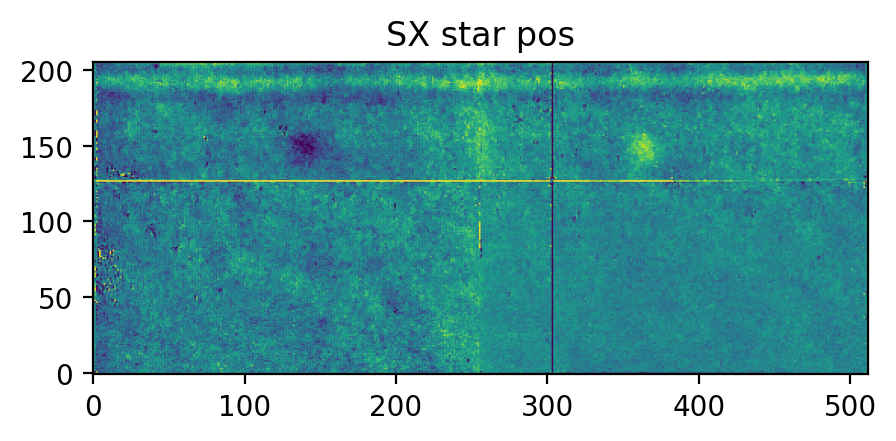

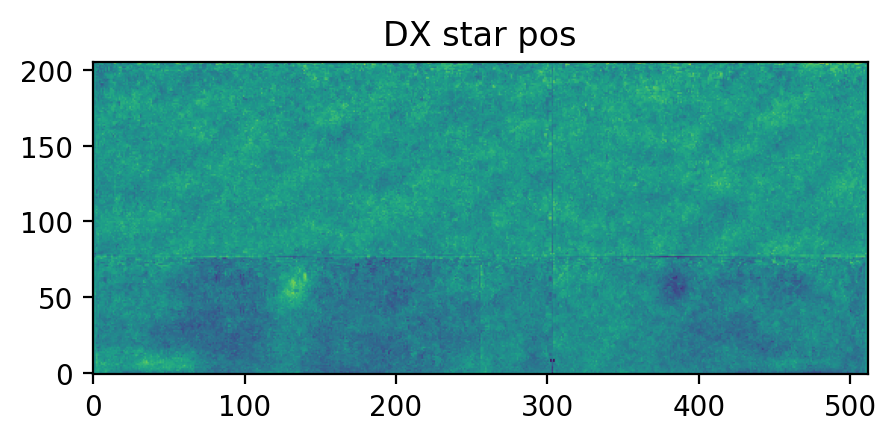

In [16]:
plt.figure(figsize=(5,5), dpi=200)
plt.title("SX star pos")
plt.imshow(sx_chopa_part/sx_chopa_flat - sx_chopb_part/sx_chopb_flat, origin="lower",
           vmin=-3e-3, vmax=3e-3)
plt.show()

plt.figure(figsize=(5,5), dpi=200)
plt.title("DX star pos")
plt.imshow(dx_chopa_part/dx_chopa_flat - dx_chopb_part/dx_chopb_flat, origin="lower")
plt.show()


In [9]:
# We create the high pass filter mask here
sx_highpassmask = np.zeros(np.shape(sx_badmap))
sx_highpassmask[130:170,:] = 1

# We create the high pass filter mask here
dx_highpassmask = np.zeros(np.shape(dx_badmap))
dx_highpassmask[30:70,:] = 1

### Subtract PSFs to aid background subtraction/calibration

We can now model and subtract the PSF from the images to create even better flats for each chop state. We can also use these PSF subtracted images for chop subtraction.

##### Star masking
First, we create masks identifying the location of the star to ensure the PSF is located in its proper position.

In [ ]:
(sx_chopa_starmask,
 sx_chopb_starmask) = prep.create_star_mask(sx_chopa_part, sx_chopb_part, sx_chopa_flat, sx_chopb_flat,
                                            sx_badmap, sx_highpassmask, smooth=2, sigma=5, growth=4)


(dx_chopa_starmask,
 dx_chopb_starmask) = prep.create_star_mask(dx_chopa_part, dx_chopb_part, dx_chopa_flat, dx_chopb_flat,
                                            dx_badmap, dx_highpassmask, smooth=2, sigma=5, growth=4)

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopa_starmask)])
hdul.writeto(obj+"_SX_chopa_starmask.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopb_starmask)])
hdul.writeto(obj+"_SX_chopb_starmask.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopa_starmask)])
hdul.writeto(obj+"_DX_chopa_starmask.fits", overwrite=True)
hdul.close()
hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopb_starmask)])
hdul.writeto(obj+"_DX_chopb_starmask.fits", overwrite=True)
hdul.close()

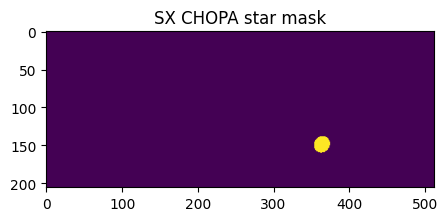

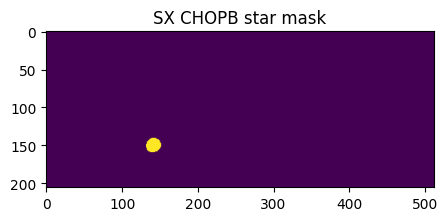

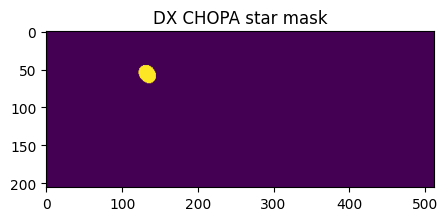

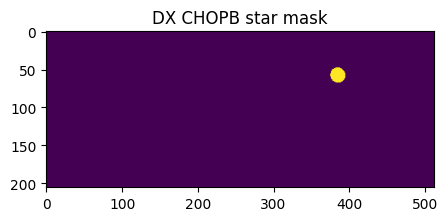

In [18]:
plt.figure(figsize=(5,5),dpi=100)
plt.title("SX CHOPA star mask")
plt.imshow(sx_chopa_starmask)#, vmin=0, vmax=1)
plt.show()

plt.figure(figsize=(5,5),dpi=100)
plt.title("SX CHOPB star mask")
plt.imshow(sx_chopb_starmask, vmin=0, vmax=1)
plt.show()

plt.figure(figsize=(5,5),dpi=100)
plt.title("DX CHOPA star mask")
plt.imshow(dx_chopa_starmask, vmin=0, vmax=1)
plt.show()

plt.figure(figsize=(5,5),dpi=100)
plt.title("DX CHOPB star mask")
plt.imshow(dx_chopb_starmask, vmin=0, vmax=1)
plt.show()

In [ ]:
(sx_psf_subtracted_files,
 sx_maxima,
 sx_failcodes) = prep.subtract_psfs(sx_files, sx_chops, stellar_temp, badmap=sx_badmap,
                                    starmask=[sx_chopa_starmask, sx_chopb_starmask],
                                    flats=[sx_chopa_flat, sx_chopb_flat],
                                    remove_trefoil=False, prefix='sx_')

np.savez(obj+"_SX_NOMIC_psf_subtraction.npz", sx_psf_subtracted_files, sx_maxima, sx_failcodes)

(dx_psf_subtracted_files,
 dx_maxima,
 dx_failcodes) = prep.subtract_psfs(dx_files, dx_chops, stellar_temp, badmap=dx_badmap,
                                    starmask=[dx_chopa_starmask, dx_chopb_starmask],
                                    flats=[dx_chopa_flat, dx_chopb_flat],
                                    remove_trefoil=False, prefix='dx_')

np.savez(obj+"_DX_NOMIC_psf_subtraction.npz", dx_psf_subtracted_files, dx_maxima, dx_failcodes)

print("Files saved")

### Monitor star positions and background positions

We can use the function hf.image_groups to look for portions of the dataset that are noticeably shifted from the rest of the dataset and remove them to ensure that we adequately correct chop residuals. We can then likewise measure the positions of the background and align the backgrounds together and avoid smaller shifts in the chop residuals.

In [13]:
sx_img_group_times, sx_img_group_pos = hf.image_groups(sx_header_info[2], sx_maxima[:,0])

dx_img_group_times, dx_img_group_pos = hf.image_groups(dx_header_info[2], dx_maxima[:,0])

Image groups: 
Image group 0:  0.14308046951591108
Image group 1:  0.8531835404467291
Image group 2:  0.11658408627222384
Image group 3:  84.81227312471847
Image group 4:  10.611801489096738
Image group 5:  0.7260009008770303
Image group 6:  0.6889059643358681
Image group 7:  0.6677088577409184
Image group 8:  1.237381097480194
Image group 9:  0.14308046951591108
Image groups: 
Image group 0:  0.1422550052687039
Image group 1:  0.8587987355110642
Image group 2:  0.11854583772391991
Image group 3:  2.368282402528978
Image group 4:  0.9220231822971549
Image group 5:  81.49631190727081
Image group 6:  11.18809272918862
Image group 7:  1.0458377239199157
Image group 8:  0.44257112750263433
Image group 9:  1.2723919915700737
Image group 10:  0.14488935721812435


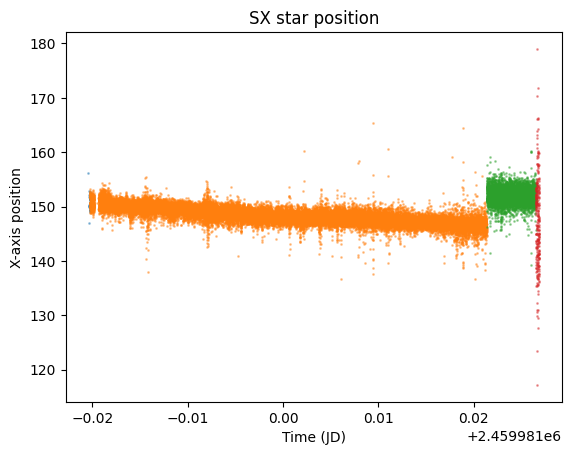

In [14]:
plt.scatter(sx_img_group_times[2], sx_img_group_pos[2], s=1, alpha=0.4)
plt.scatter(sx_img_group_times[3], sx_img_group_pos[3], s=1, alpha=0.4)
plt.scatter(sx_img_group_times[4], sx_img_group_pos[4], s=1, alpha=0.4)
plt.scatter(sx_img_group_times[5], sx_img_group_pos[5], s=1, alpha=0.4)
#plt.xlim(2459981.0212, 2459981.0217)
plt.xlabel("Time (JD)")
plt.ylabel("X-axis position")
plt.title("SX star position")
plt.show()

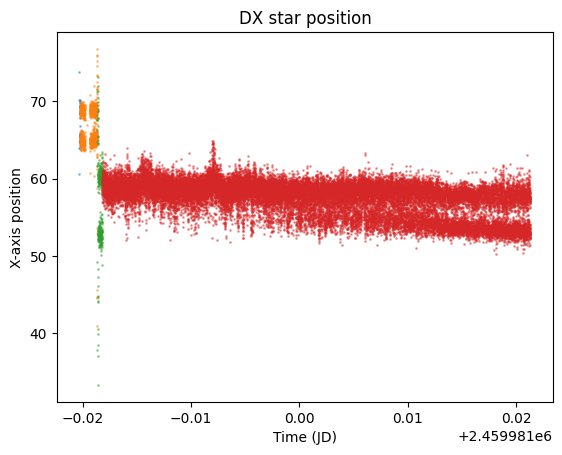

In [15]:
plt.scatter(dx_img_group_times[2], dx_img_group_pos[2], s=1, alpha=0.4)
plt.scatter(dx_img_group_times[3], dx_img_group_pos[3], s=1, alpha=0.4)
plt.scatter(dx_img_group_times[4], dx_img_group_pos[4], s=1, alpha=0.4)
plt.scatter(dx_img_group_times[5], dx_img_group_pos[5], s=1, alpha=0.4)
#plt.xlim(2459981.0212, 2459981.0217)
plt.xlabel("Time (JD)")
plt.ylabel("X-axis position")
plt.title("DX star position")
plt.show()

### Create flats for each chop state

In [18]:
_, sx_chopa_flat, sx_chopb_flat =\
           prep.create_stacked_flat(sx_psf_subtracted_files[np.isin(sx_header_info[2],
                                                                    sx_img_group_times[3])],
                                    sx_chops[np.isin(sx_header_info[2],sx_img_group_times[3])],
                                    buffer_type="files", method="mean",
                                    chop_direction="LEFT-RIGHT", tolerance=0.2)

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopa_flat)])
hdul.writeto(obj+"_SX_chopa_flat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=sx_chopb_flat)])
hdul.writeto(obj+"_SX_chopb_flat.fits", overwrite=True)
hdul.close()

_, dx_chopa_flat, dx_chopb_flat =\
           prep.create_stacked_flat(dx_psf_subtracted_files[np.isin(dx_header_info[2],
                                                                    dx_img_group_times[5])],
                                    dx_chops[np.isin(dx_header_info[2],dx_img_group_times[5])],
                                    buffer_type="files", method="mean",
                                    chop_direction="LEFT-RIGHT", tolerance=0.2)

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopa_flat)])
hdul.writeto(obj+"_DX_chopa_flat.fits", overwrite=True)
hdul.close()

hdul = fits.HDUList([fits.PrimaryHDU(data=dx_chopb_flat)])
hdul.writeto(obj+"_DX_chopb_flat.fits", overwrite=True)
hdul.close()

print("Flats saved")

Creating integrated files for correlation...
Using a buffer of  571  frames...


integrating files:   0%|          | 0/28 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  571  frames...


integrating files:   0%|          | 0/28 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  572  frames...


integrating files:   0%|          | 0/27 [00:00<?, ?it/s]

Creating integrated files for correlation...
Using a buffer of  572  frames...


integrating files:   0%|          | 0/27 [00:00<?, ?it/s]

Flats saved


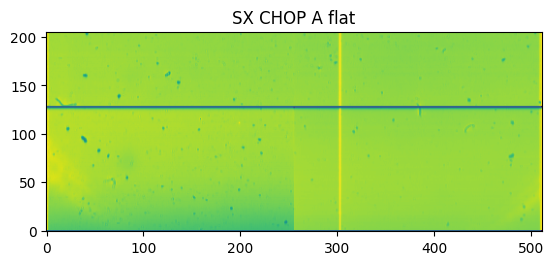

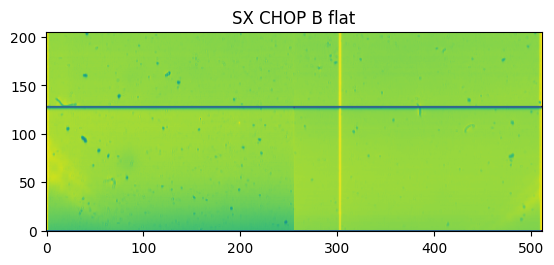

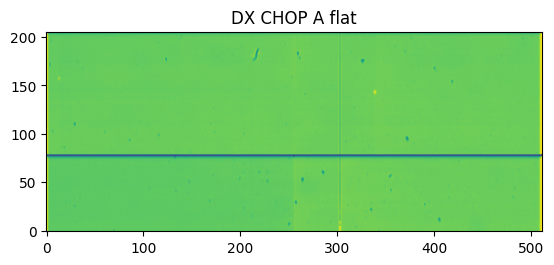

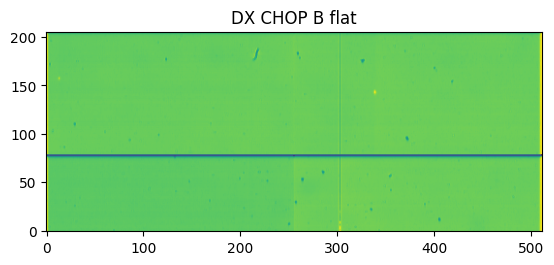

In [19]:
plt.title("SX CHOP A flat")
plt.imshow(sx_chopa_flat, origin="lower")#, vmin=16000, vmax=35000)
plt.show()
plt.title("SX CHOP B flat")
plt.imshow(sx_chopb_flat, origin="lower")#, vmin=16000, vmax=35000)
plt.show()
plt.title("DX CHOP A flat")
plt.imshow(dx_chopa_flat, origin="lower")#, vmin=16000, vmax=35000)
plt.show()
plt.title("DX CHOP B flat")
plt.imshow(dx_chopb_flat, origin="lower")#, vmin=16000, vmax=35000)
plt.show()

## Background subtraction

We now create background subtracted (and flat calibrated) images, with some image repair as well to deal with NOMIC systematics (striped regions, biases). These images are saved in a directory.

In [ ]:
sx_subtracted_dir = prep.subtract_background(sx_files, sx_psf_subtracted_files,
                                             sx_chops, flats=[sx_chopa_flat,
                                                              sx_chopb_flat],
                                             prefix="sx_", channel_edges=[127],
                                             biased_columns=[303],
                                             striped_regions=[[0, 124, 255,
                                                               304, -3],
                                                              [0, 124, 304,
                                                               -3, -3]],
                                             vertical_biases=[256])

dx_subtracted_dir = prep.subtract_background(dx_files, dx_psf_subtracted_files,
                                             dx_chops, flats=[dx_chopa_flat,
                                                              dx_chopb_flat],
                                             prefix="dx_", channel_edges=[77],
                                             biased_columns=[303],
                                             horizontal_biases=[77])

In [ ]:
# Important to sort the data for reading it sequentially
sx_subtracted_files = sorted(list(pathlib.Path(str(sx_subtracted_dir))\
                       .rglob('*.fits')))
sx_subtracted_files = np.asarray([a for a in sx_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==sx_subtracted_dir])

dx_subtracted_files = sorted(list(pathlib.Path(str(dx_subtracted_dir))\
                       .rglob('*.fits')))
dx_subtracted_files = np.asarray([a for a in dx_subtracted_files\
                                   if a.name[0]!='.'\
                                   and str(a.parent)==dx_subtracted_dir])


hdul = fits.open(sx_subtracted_files[15700])
sx_img = hdul[0].data
hdul.close()

hdul = fits.open(dx_subtracted_files[5005])
dx_img = hdul[0].data
hdul.close()

plt.title("SX Background subtracted frame")
plt.imshow(sx_img, origin="lower", vmin=-100, vmax=100)
plt.show()

plt.title("DX Background subtracted frame")
plt.imshow(dx_img, origin="lower", vmin=-100, vmax=100)
plt.show()

### Frame registration
We now align the frames and place the PSFs at the center of the image. We obtain other parameters as well, including image characteristics and gaussian model fits.

In [ ]:
(sx_original_psf_locs,
 sx_imgfits,
 sx_array_shape,
 sx_file_size,
 sx_aligned_files) = prep.frame_registration(sx_files, sx_subtracted_dir,
                                             stellar_temp=stellar_temp, maxima=sx_maxima,
                                             prefix="sx_", interp_method="linear", model_trefoil=False)

np.savez(obj+"_SX_NOMIC_aligned.npz", sx_aligned_files, sx_original_psf_locs,
         sx_imgfits, sx_array_shape, sx_file_size)

(dx_original_psf_locs,
 dx_imgfits,
 dx_array_shape,
 dx_file_size,
 dx_aligned_files) = prep.frame_registration(dx_files, dx_subtracted_dir,
                                             stellar_temp=stellar_temp, maxima=dx_maxima,
                                             prefix="dx_", interp_method="linear", model_trefoil=False)


np.savez(obj+"_DX_NOMIC_aligned.npz", dx_aligned_files, dx_original_psf_locs, 
         dx_imgfits, dx_array_shape, dx_file_size)

#shutil.rmtree(sx_subtracted_dir)
#shutil.rmtree(dx_subtracted_dir)

print("Files saved")

In [ ]:
plt.title("SX Aligned frame")
hdul = fits.open(sx_aligned_files[11900])
plt.imshow(hdul[0].data)
hdul.close()
plt.show()

plt.title("DX Aligned frame")
hdul = fits.open(dx_aligned_files[31901])
plt.imshow(hdul[0].data)
hdul.close()
plt.show()

### Frame evaluation
We now evaluate the frames to get properties including fwhms, background deviation, maxima, etc.

In [51]:
(sx_fwhms, 
 sx_eccentricities,
 sx_psfmaxima,
 sx_background_dev,
 sx_correlations, 
 sx_residual_dev,
 sx_lbtfits,
 sx_reffits,
 _) =   fe.frame_evaluation(sx_aligned_files, sx_chops, sx_array_shape,
                            sx_file_size, stellar_temp, tolerance=0.2)

(dx_fwhms,
 dx_eccentricities,
 dx_psfmaxima,
 dx_background_dev,
 dx_correlations,
 dx_residual_dev,
 dx_lbtfits,
 dx_reffits,
 _) =   fe.frame_evaluation(dx_aligned_files, dx_chops, dx_array_shape,
                            dx_file_size, stellar_temp, tolerance=0.2)


np.savez(obj+"_SX_NOMIC_evaluated.npz", sx_fwhms, sx_eccentricities,
         sx_psfmaxima, sx_background_dev, sx_correlations, sx_residual_dev,
         sx_lbtfits, sx_reffits)

np.savez(obj+"_DX_NOMIC_evaluated.npz", dx_fwhms, dx_eccentricities,
         dx_psfmaxima, dx_background_dev, dx_correlations, dx_residual_dev,
         dx_lbtfits, dx_reffits)

print("Files saved")

integrating files:   0%|          | 0/73 [00:00<?, ?it/s]

/home/vivekvijayakumar/nomic/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1216: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


integrating files:   0%|          | 0/73 [00:00<?, ?it/s]

Evaluating frames...:   0%|          | 0/37960 [00:00<?, ?it/s]

/media/vivekvijayakumar/LargeSSD/GJ504/pyNOMIC/helper_functions.py:830: RuntimeWarning: invalid value encountered in divide
  model = (amp/(1-e**2)**2) * (2*j1(rad)/rad - 2*e*j1(e*rad)/rad)**2 + offset
/home/vivekvijayakumar/nomic/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Files saved


/media/vivekvijayakumar/LargeSSD/GJ504/pyNOMIC/frame_evaluation.py:438: RuntimeWarning: invalid value encountered in sqrt
  eccentricities = np.sqrt(1 - sigmax/sigmay)
/media/vivekvijayakumar/LargeSSD/GJ504/pyNOMIC/frame_evaluation.py:439: RuntimeWarning: invalid value encountered in sqrt
  eccentricities_r = np.sqrt(1 - sigmay/sigmax)


### Frame rejection and binning
We can do a first round of rejection using frame properties, and then bin the frames and obtain the binned frame properties.

In [ ]:
sx_frame_bool = fe.frame_rejection(sx_chops,
                                     [sx_fwhms, sx_eccentricities])

print("Percent of frames kept in SX: ",
      100*len(sx_frame_bool[sx_frame_bool == True])/len(sx_frame_bool))

dx_frame_bool = fe.frame_rejection(dx_chops,
                                     [dx_fwhms, dx_eccentricities)

print("Percent of frames kept in SX: ",
      100*len(sx_frame_bool[sx_frame_bool == True])/len(sx_frame_bool))

In [52]:
(sx_binned_files,
 sx_binned_chops,
 sx_binned_angles) = fe.frame_binning(sx_aligned_files, sx_chops,
                                        sx_header_info[1], sx_frame_bool,
                                        sx_array_shape, prefix="sx_", bin=200)
(dx_binned_files,
 dx_binned_chops,
 dx_binned_angles) = fe.frame_binning(dx_aligned_files, dx_chops,
                                        dx_header_info[1], dx_frame_bool,
                                        dx_array_shape, prefix="dx_", bin=200)

(sx_binned_fwhms,
 sx_binned_eccs,
 sx_binned_psfmax,
 sx_binned_backdev,
 sx_binned_corrs,
 sx_binned_residual_dev,
 sx_binned_lbtfits,
 sx_binned_reffits,
 _) = fe.frame_evaluation(sx_binned_files, sx_binned_chops, sx_array_shape,
                            sx_file_size, stellar_temp=stellar_temp,
                            tolerance=0.2)

np.savez(obj+"_SX_NOMIC_binned_evaluated.npz", sx_binned_fwhms, sx_binned_eccs,
         sx_binned_psfmax, sx_binned_backdev, sx_binned_corrs,
         sx_binned_residual_dev, sx_binned_lbtfits,
         sx_binned_reffits, sx_binned_files, sx_binned_chops, sx_binned_angles)

(dx_binned_fwhms,
 dx_binned_eccs,
 dx_binned_psfmax,
 dx_binned_backdev,
 dx_binned_corrs,
 dx_binned_residual_dev,
 dx_binned_lbtfits,
 dx_binned_reffits,
 _) = fe.frame_evaluation(dx_binned_files, dx_binned_chops, dx_array_shape,
                            dx_file_size, stellar_temp=stellar_temp,
                            tolerance=0.2)

np.savez(obj+"_DX_NOMIC_binned_evaluated.npz", dx_binned_fwhms, dx_binned_eccs,
         dx_binned_psfmax, dx_binned_backdev, dx_binned_corrs,
         dx_binned_residual_dev, dx_binned_lbtfits,
         dx_binned_reffits, dx_binned_files, dx_binned_chops, dx_binned_angles)

print("Files saved")

Binning files...


0it [00:00, ?it/s]

/media/vivekvijayakumar/LargeSSD/GJ504/pyNOMIC/helper_functions.py:76: RuntimeWarning: Mean of empty slice
  stacked_img = np.nanmean(buf_3D, axis=0)*count


0it [00:00, ?it/s]

integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

/media/vivekvijayakumar/LargeSSD/GJ504/pyNOMIC/helper_functions.py:139: RuntimeWarning: All-NaN slice encountered
  frame_fragment = np.nanmedian(buf_3D, axis=0)


integrating files:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating frames...:   0%|          | 0/141 [00:00<?, ?it/s]

Files saved


### Injection and PCA
We can inject a source into the image cube and perform PCA to recover the source.

In [54]:
from pyNOMIC.contrast_estimation import inject_source

injected_frames, injected_shape = inject_planet(dx_binned_files,
                                                dx_binned_angles,
                                                dx_binned_reffits,
                                                dx_array_shape,
                                                injection_radius = 40, injection_angle=180, 
                                                contrast=1e-2, highpassrad=None,crop_size=284)

  0%|          | 0/141 [00:00<?, ?it/s]

In [56]:
from pyNOMIC.vip_pca_functions import pca
from vip_hci.psfsub import pca_annular

dx_med_image_chopa = pca(dx_image_cube[dx_binned_chops == "CHOP_A"],
                         dx_binned_angles[dx_binned_chops == "CHOP_A"],
                         ncomp=8, nproc=1, svd_mode='eigen',
                         imlib='opencv', collapse='median')
dx_med_image_chopb = pca(dx_image_cube[dx_binned_chops == "CHOP_B"],
                         dx_binned_angles[dx_binned_chops == "CHOP_B"],
                         ncomp=8, nproc=1, svd_mode='eigen',
                         imlib='opencv', collapse='median')

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-06-29 12:23:09
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
System total memory = 134.771 GB
System available memory = 126.018 GB
Done vectorizing the frames. Matrix shape: (68, 80656)
Done PCA with numpy linalg eigh functions
Running time:  0:00:00.198381
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Done de-rotating and combining
Running time:  0:00:00.725574
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-06-29 12:23:10
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
System total memory = 134.771 GB
System available memory = 126.033 GB
Done vectorizing the frames. Matrix shape: (73, 80656)
Done PCA with numpy linalg eigh functions
Running time:  0:00

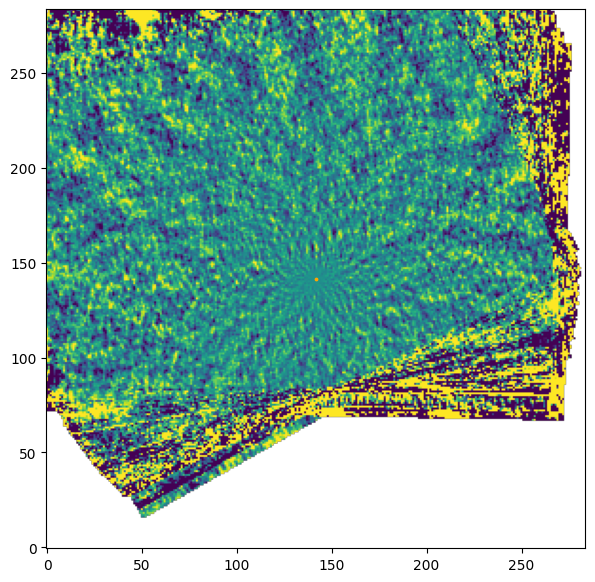

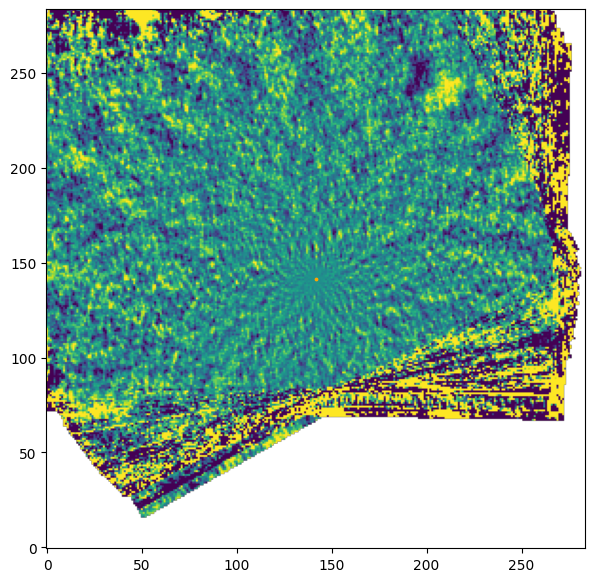

In [57]:
plt.figure(figsize=(7,7), dpi=100)
plt.imshow(dx_med_image_chopb, vmin=-1e-3, vmax=1e-3, origin="lower")
plt.scatter(141.5, 141.5, s=3,color="orange")
plt.show()
plt.figure(figsize=(7,7), dpi=100)
plt.imshow(injected_med, vmin=-1e-3, vmax=1e-3, origin="lower")
plt.scatter(141.5, 141.5, s=3,color="orange")
plt.show()